## Precipitation Analysis: CNTL, P4K, 4CO2 Experiments

In [21]:
# Load packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmaps
from matplotlib.colors import LinearSegmentedColormap

print("="*70)
print("✅ Packages loaded successfully")
print("="*70)

# Set up directories
DATA_DIR = "./processed_data"
fig_save_dir = "./figures/Cal_precipitation/"
os.makedirs(fig_save_dir, exist_ok=True)

print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Figure save directory: {fig_save_dir}")
print("="*70)

# Create custom colormap
def create_improved_colormap():
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

✅ Packages loaded successfully
📁 Data directory: ./processed_data
📁 Figure save directory: ./figures/Cal_precipitation/


In [22]:
# Load ocean mask
print("="*70)
print("🌊 Loading ocean mask")
print("="*70)

ocean_mask_path = os.path.join(DATA_DIR, "ocean_mask_2deg.nc")
if os.path.exists(ocean_mask_path):
    ocean_mask_2deg_binary = xr.open_dataarray(ocean_mask_path)
    print(f"✅ Ocean mask loaded! Shape: {ocean_mask_2deg_binary.shape}")
else:
    print("⚠️  Ocean mask not found, will process all data without masking")
    ocean_mask_2deg_binary = None

print("="*70)

🌊 Loading ocean mask
✅ Ocean mask loaded! Shape: (15, 180)


In [23]:
# Step 1: Load precipitation data
print("="*70)
print("📊 Loading precipitation data")
print("="*70)

# Define file paths
pr_files = {
    'CNTL': os.path.join(DATA_DIR, 'pr_cntl_2deg_interp.nc'),
    'P4K': os.path.join(DATA_DIR, 'pr_4k_2deg_interp.nc'),
    '4CO2': os.path.join(DATA_DIR, 'pr_4co2_2deg_interp.nc')
}

# Load data
pr_data = {}
for exp, file_path in pr_files.items():
    try:
        data = xr.open_dataarray(file_path)
        # Convert from kg/m²/s to mm/day (multiply by 86400)
        pr_data[exp] = data * 86400
        print(f"✅ {exp}: {pr_data[exp].shape} - Converted to mm/day")
    except Exception as e:
        print(f"❌ {exp}: Failed to load - {str(e)}")

print("\n" + "="*70)
print("✅ Precipitation data loaded successfully")
print("="*70)

📊 Loading precipitation data
✅ CNTL: (5114, 15, 180) - Converted to mm/day
✅ CNTL: (5114, 15, 180) - Converted to mm/day
✅ P4K: (5114, 15, 180) - Converted to mm/day
✅ P4K: (5114, 15, 180) - Converted to mm/day
✅ 4CO2: (5114, 15, 180) - Converted to mm/day

✅ Precipitation data loaded successfully
✅ 4CO2: (5114, 15, 180) - Converted to mm/day

✅ Precipitation data loaded successfully


In [24]:
# Step 2: Calculate climatology
print("="*70)
print("🧮 Calculating precipitation climatology")
print("="*70)

# Calculate time-mean climatology
pr_clim = {}
for exp in ['CNTL', 'P4K', '4CO2']:
    if exp in pr_data:
        pr_clim[exp] = pr_data[exp].mean(dim='time')
        print(f"✅ {exp} climatology calculated")

# Apply ocean mask if available
if ocean_mask_2deg_binary is not None:
    pr_clim_ocean = {}
    for exp, data in pr_clim.items():
        pr_clim_ocean[exp] = data
        print(f"✅ {exp} ocean mask applied")
else:
    pr_clim_ocean = pr_clim

print("\n" + "="*70)
print("✅ Climatology calculation complete")
print("="*70)

🧮 Calculating precipitation climatology
✅ CNTL climatology calculated
✅ P4K climatology calculated
✅ 4CO2 climatology calculated
✅ CNTL ocean mask applied
✅ P4K ocean mask applied
✅ 4CO2 ocean mask applied

✅ Climatology calculation complete
✅ 4CO2 climatology calculated
✅ CNTL ocean mask applied
✅ P4K ocean mask applied
✅ 4CO2 ocean mask applied

✅ Climatology calculation complete


In [25]:
# Step 3: Calculate differences
print("="*70)
print("📈 Calculating precipitation differences")
print("="*70)

# Calculate differences relative to CNTL
pr_diff = {
    'P4K-CNTL': pr_clim['P4K'] - pr_clim['CNTL'],
    '4CO2-CNTL': pr_clim['4CO2'] - pr_clim['CNTL']
}

# Apply ocean mask to differences if available
if ocean_mask_2deg_binary is not None:
    pr_diff_ocean = {}
    for diff_name, data in pr_diff.items():
        pr_diff_ocean[diff_name] = data.where(ocean_mask_2deg_binary == 1)
        print(f"✅ {diff_name} calculated (ocean only)")
else:
    pr_diff_ocean = pr_diff
    for diff_name in pr_diff.keys():
        print(f"✅ {diff_name} calculated")

print("\n" + "="*70)
print("✅ Difference calculation complete")
print("="*70)

📈 Calculating precipitation differences
✅ P4K-CNTL calculated (ocean only)
✅ 4CO2-CNTL calculated (ocean only)

✅ Difference calculation complete


In [26]:
# Step 4: Calculate tropical mean statistics
print("="*70)
print("📊 Calculating tropical mean precipitation (15°S-15°N)")
print("="*70)

def tropical_mean(data, lat_range=(-15, 15)):
    """Calculate tropical mean"""
    return data.sel(lat=slice(*lat_range)).mean(dim=['lat', 'lon'])

# Calculate tropical means
print("\nClimatology (mm/day):")
print("-"*70)
print(f"{'Experiment':<15} {'Tropical Mean':>15} {'Global Mean':>15}")
print("-"*70)

for exp in ['CNTL', 'P4K', '4CO2']:
    if exp in pr_clim_ocean:
        trop_mean = float(tropical_mean(pr_clim_ocean[exp]))
        glob_mean = float(pr_clim_ocean[exp].mean())
        print(f"{exp:<15} {trop_mean:>15.2f} {glob_mean:>15.2f}")

print("\nDifferences (mm/day):")
print("-"*70)
print(f"{'Difference':<15} {'Tropical Mean':>15} {'Global Mean':>15}")
print("-"*70)

for diff_name in ['P4K-CNTL', '4CO2-CNTL']:
    if diff_name in pr_diff_ocean:
        trop_mean = float(tropical_mean(pr_diff_ocean[diff_name]))
        glob_mean = float(pr_diff_ocean[diff_name].mean())
        print(f"{diff_name:<15} {trop_mean:>+15.2f} {glob_mean:>+15.2f}")

print("="*70)

📊 Calculating tropical mean precipitation (15°S-15°N)

Climatology (mm/day):
----------------------------------------------------------------------
Experiment        Tropical Mean     Global Mean
----------------------------------------------------------------------
CNTL                       5.26            5.26
P4K                        5.94            5.94
4CO2                       5.07            5.07

Differences (mm/day):
----------------------------------------------------------------------
Difference        Tropical Mean     Global Mean
----------------------------------------------------------------------
P4K-CNTL                  +0.86           +0.86
4CO2-CNTL                 -0.35           -0.35


📊 Plotting precipitation climatology
✅ Saved: ./figures/Cal_precipitation/precipitation_climatology.png
✅ Saved: ./figures/Cal_precipitation/precipitation_climatology.png


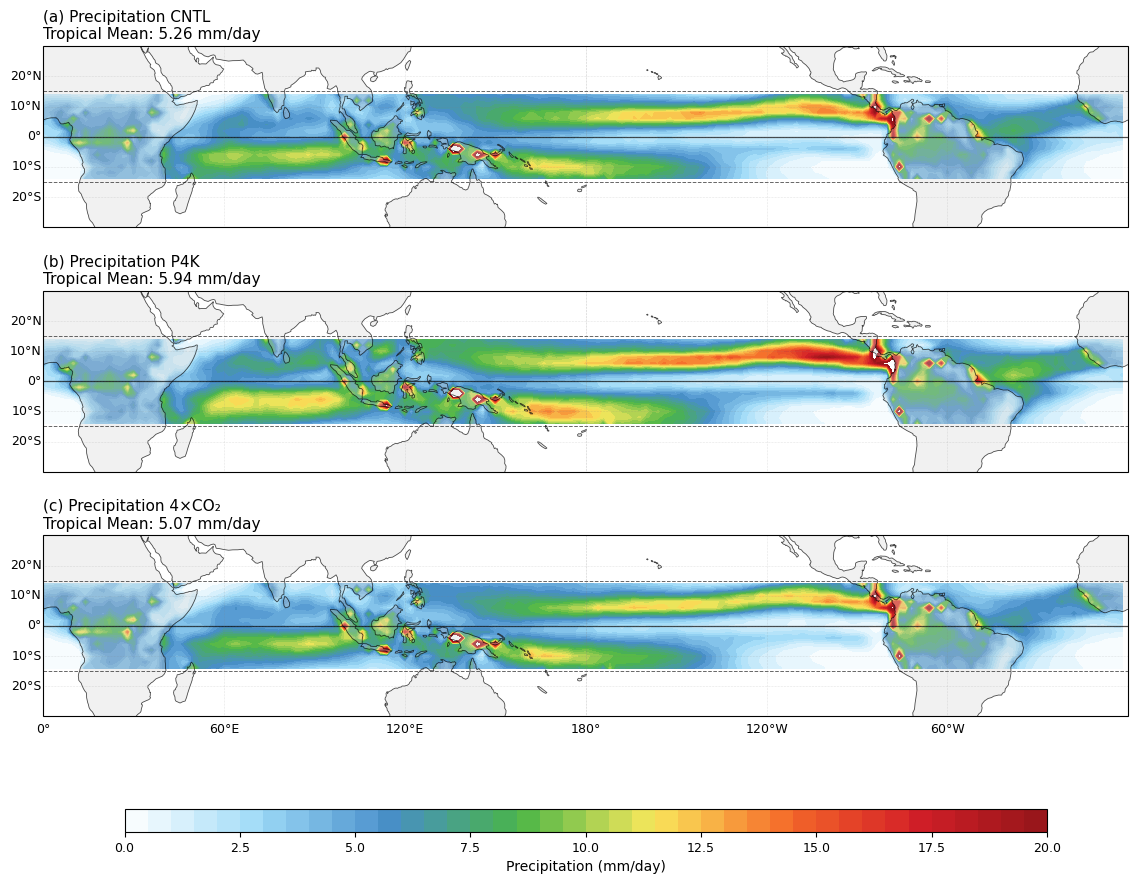

In [30]:
# Step 5: Visualize climatology (3 experiments)
print("="*70)
print("📊 Plotting precipitation climatology")
print("="*70)

# Prepare data
field_list = [
    pr_clim_ocean['CNTL'],
    pr_clim_ocean['P4K'],
    pr_clim_ocean['4CO2']
]

titles = [
    '(a) Precipitation CNTL',
    '(b) Precipitation P4K',
    '(c) Precipitation 4×CO₂'
]

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Plot settings
lat_lim = (-30, 30)
lon_lim = (0, 360)
vmin, vmax = 0, 20 # mm/day
levels = 41

for i, (ax, data, title) in enumerate(zip(axes, field_list, titles)):
    # Plot filled contours
    im = ax.contourf(
        data.lon, data.lat, data,
        levels=np.linspace(vmin, vmax, levels),
        cmap=cmaps.WhiteBlueGreenYellowRed,
        extend='neither',
        transform=ccrs.PlateCarree()
    )
    
    # Set map extent
    ax.set_extent([lon_lim[0], lon_lim[1], lat_lim[0], lat_lim[1]], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.coastlines(linewidth=0.6, color='black', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
    
    # Add latitude lines
    ax.axhline(y=15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=-15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.9, alpha=0.7, zorder=2)
    
    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle=':', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    if i < 2:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    
    # Calculate tropical mean
    trop_mean = float(tropical_mean(data))
    
    # Title with tropical mean
    ax.set_title(f'{title}\nTropical Mean: {trop_mean:.2f} mm/day', 
                fontsize=11, loc='left', pad=5, )
    
    # Add colorbar
cb = plt.colorbar(im, ax=axes, orientation='horizontal', 
                    pad=0.1, aspect=40, shrink=0.85)
cb.set_label('Precipitation (mm/day)', fontsize=10, )
cb.ax.tick_params(labelsize=9)

# plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'precipitation_climatology.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {save_path}")
plt.show()

print("="*70)

📊 Plotting precipitation differences
✅ Saved: ./figures/Cal_precipitation/precipitation_differences.png
✅ Saved: ./figures/Cal_precipitation/precipitation_differences.png


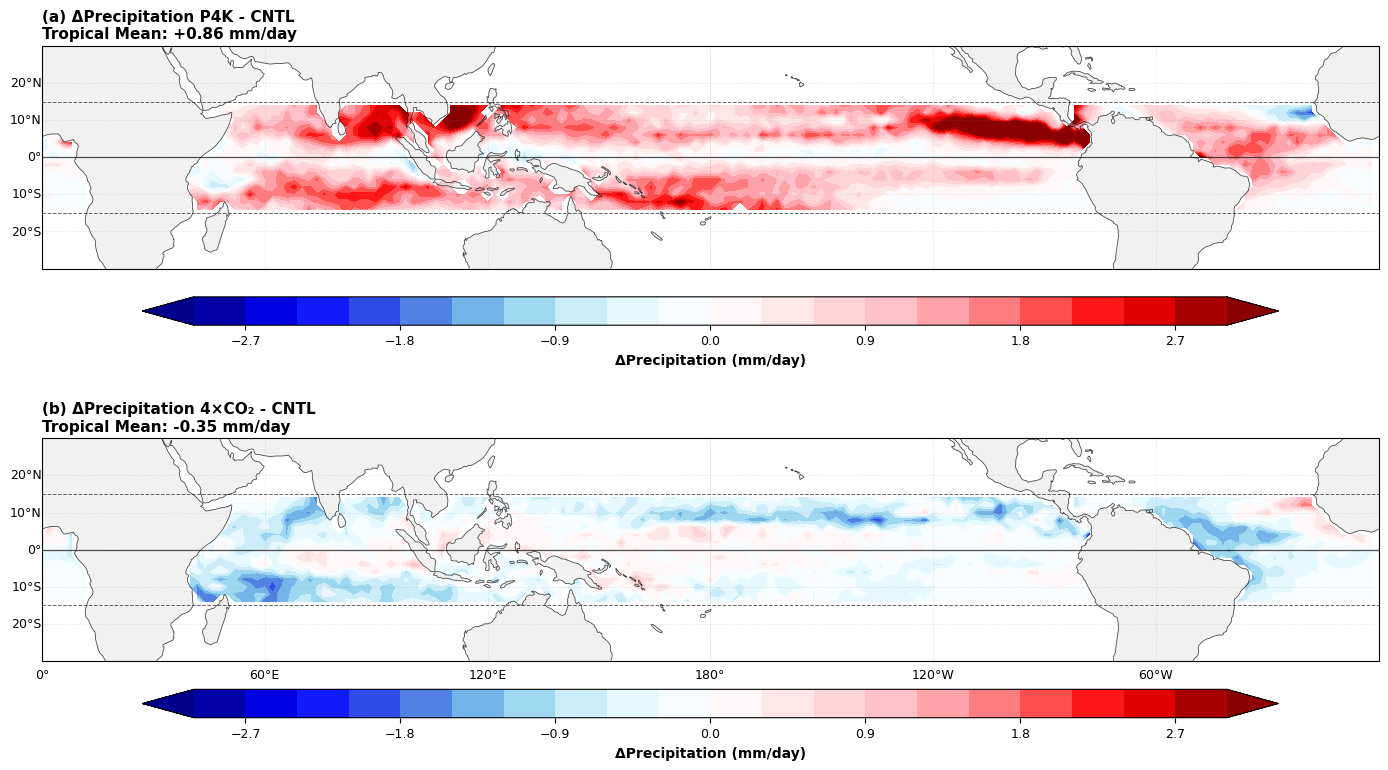

In [28]:
# Step 6: Visualize differences (P4K-CNTL and 4CO2-CNTL)
print("="*70)
print("📊 Plotting precipitation differences")
print("="*70)

# Prepare data
field_list_diff = [
    pr_diff_ocean['P4K-CNTL'],
    pr_diff_ocean['4CO2-CNTL']
]

titles_diff = [
    '(a) ΔPrecipitation P4K - CNTL',
    '(b) ΔPrecipitation 4×CO₂ - CNTL'
]

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 8), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Plot settings
lat_lim = (-30, 30)
lon_lim = (0, 360)
vmin, vmax = -3, 3  # mm/day
levels = 21

for i, (ax, data, title) in enumerate(zip(axes, field_list_diff, titles_diff)):
    # Plot filled contours
    im = ax.contourf(
        data.lon, data.lat, data,
        levels=np.linspace(vmin, vmax, levels),
        cmap=mycmap,
        extend='both',
        transform=ccrs.PlateCarree()
    )
    
    # Set map extent
    ax.set_extent([lon_lim[0], lon_lim[1], lat_lim[0], lat_lim[1]], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.coastlines(linewidth=0.6, color='black', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
    
    # Add latitude lines
    ax.axhline(y=15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=-15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.9, alpha=0.7, zorder=2)
    
    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle=':', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    if i < 1:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    
    # Calculate tropical mean
    trop_mean = float(tropical_mean(data))
    
    # Title with tropical mean
    ax.set_title(f'{title}\nTropical Mean: {trop_mean:+.2f} mm/day', 
                fontsize=11, loc='left', pad=5, fontweight='bold')
    
    # Add colorbar
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', 
                     pad=0.08, aspect=40, shrink=0.85)
    cb.set_label('ΔPrecipitation (mm/day)', fontsize=10, fontweight='bold')
    cb.ax.tick_params(labelsize=9)

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'precipitation_differences.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {save_path}")
plt.show()

print("="*70)

📊 Plotting combined precipitation analysis (2×3 layout)
✅ Saved: ./figures/Cal_precipitation/precipitation_combined_2x3.png
✅ Saved: ./figures/Cal_precipitation/precipitation_combined_2x3.png


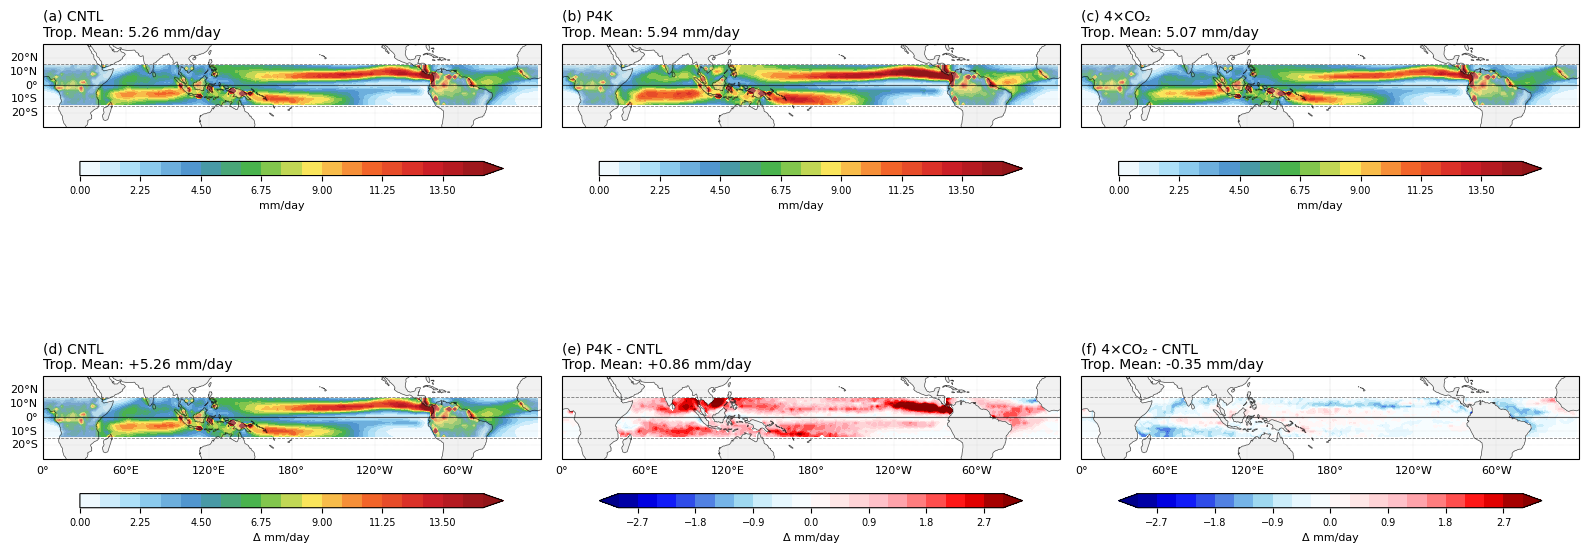

In [29]:
# Step 7: Combined visualization (climatology + differences)
print("="*70)
print("📊 Plotting combined precipitation analysis (2×3 layout)")
print("="*70)

# Prepare data for 2×3 layout
# Row 1: Climatology (CNTL, P4K, 4CO2)
# Row 2: CNTL, P4K-CNTL, 4CO2-CNTL
field_list_combined = [
    pr_clim_ocean['CNTL'], pr_clim_ocean['P4K'], pr_clim_ocean['4CO2'],
    pr_clim_ocean['CNTL'], pr_diff_ocean['P4K-CNTL'], pr_diff_ocean['4CO2-CNTL']
]

titles_combined = [
    '(a) CNTL', '(b) P4K', '(c) 4×CO₂',
    '(d) CNTL', '(e) P4K - CNTL', '(f) 4×CO₂ - CNTL'
]

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(16, 8), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

# Plot settings
lat_lim = (-30, 30)
lon_lim = (0, 360)

# Different color ranges for climatology and differences
vmins = [0, 0, 0, 0, -3, -3]
vmaxs = [15, 15, 15, 15, 3, 3]
cmaps_list = [
    cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed,
    cmaps.WhiteBlueGreenYellowRed, mycmap, mycmap
]
extends = ['max', 'max', 'max', 'max', 'both', 'both']

for i, (ax, data, title) in enumerate(zip(axes, field_list_combined, titles_combined)):
    # Plot filled contours
    im = ax.contourf(
        data.lon, data.lat, data,
        levels=np.linspace(vmins[i], vmaxs[i], 21),
        cmap=cmaps_list[i],
        extend=extends[i],
        transform=ccrs.PlateCarree()
    )
    
    # Set map extent
    ax.set_extent([lon_lim[0], lon_lim[1], lat_lim[0], lat_lim[1]], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.coastlines(linewidth=0.5, color='black', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
    
    # Add latitude lines
    ax.axhline(y=15, color='black', linestyle='--', linewidth=0.6, alpha=0.5, zorder=2)
    ax.axhline(y=-15, color='black', linestyle='--', linewidth=0.6, alpha=0.5, zorder=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.6, zorder=2)
    
    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, linestyle=':', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    
    # Control labels
    if i % 3 != 0:  # Not left column
        gl.left_labels = False
    if i < 3:  # Top row
        gl.bottom_labels = False
    
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    
    # Calculate tropical mean
    trop_mean = float(tropical_mean(data))
    
    # Title with tropical mean
    if i < 3:
        ax.set_title(f'{title}\nTrop. Mean: {trop_mean:.2f} mm/day', 
                    fontsize=10, loc='left', pad=5)
    else:
        ax.set_title(f'{title}\nTrop. Mean: {trop_mean:+.2f} mm/day', 
                    fontsize=10, loc='left', pad=5)
    
    # Add colorbar
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', 
                     pad=0.08, aspect=30, shrink=0.85)
    if i < 3:
        cb.set_label('mm/day', fontsize=8)
    else:
        cb.set_label('Δ mm/day', fontsize=8)
    cb.ax.tick_params(labelsize=7)

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'precipitation_combined_2x3.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {save_path}")
plt.show()

print("="*70)

## Summary

This notebook analyzed precipitation patterns across three climate experiments:

1. **CNTL**: Control experiment
2. **P4K**: SST +4K experiment
3. **4CO2**: Quadrupled CO₂ experiment

### Key Outputs:
- Precipitation climatology for each experiment
- Precipitation differences (P4K-CNTL and 4CO2-CNTL)
- Tropical mean statistics (15°S-15°N)
- High-resolution spatial distribution maps

### Physical Interpretation:
- **P4K**: Enhanced evaporation from warmer SST → increased precipitation
- **4CO2**: Radiative forcing effects → complex precipitation response with regional variations

- https://gpm.nasa.gov/data/imerg/precipitation-climatology

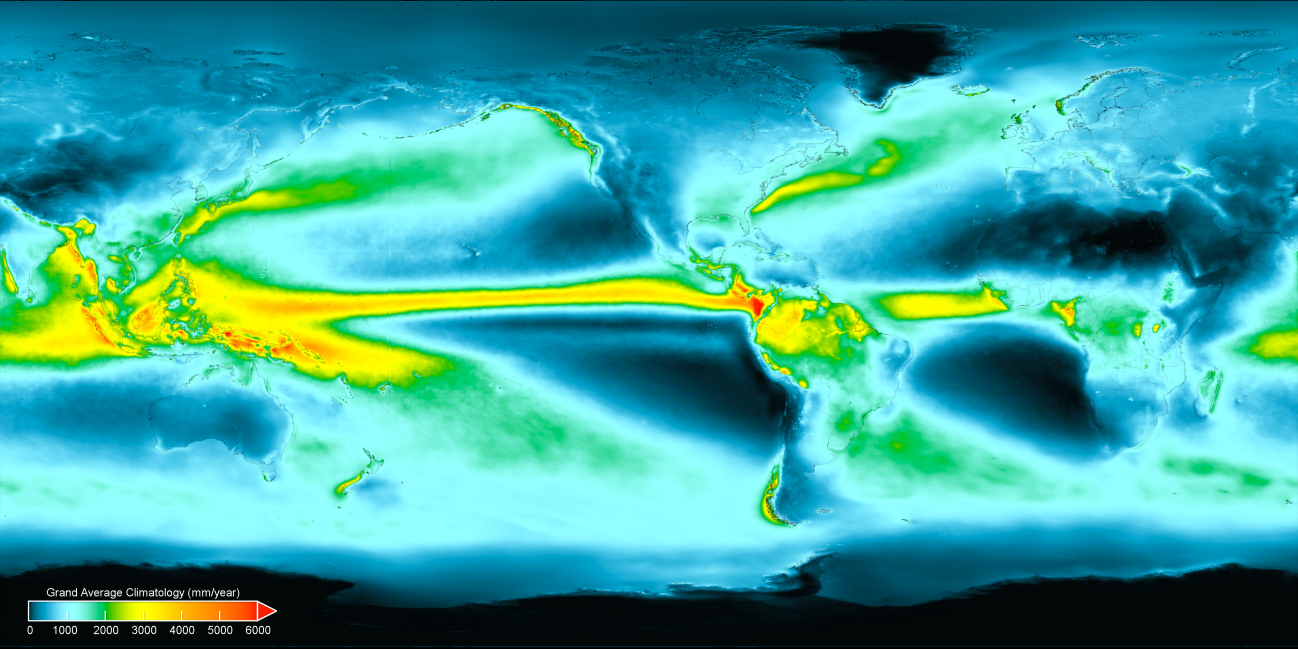